<a href="https://colab.research.google.com/github/chutimabo-ctrl/Pandas-review/blob/main/Part1_Social_Listening_Warm_up.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Part 1: Social Listening Warm-up
*งานเดี่ยว — ทุกคนต้องทำและส่งของตนเอง ไม่ต้องนำเสนอ (10 คะแนน)*

ใช้ข้อมูลโพสต์สาธารณะจาก **Bluesky**  
https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

ใช้เพียง **1–3 ไฟล์** ก็พอ ไม่จำเป็นต้องโหลดทั้ง dataset

ฟิลด์ที่มี เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`, `predicted_language`

## ตอบ 4 คำถามหลัก

1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ
4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

> Part 1 เป็น warm-up ไม่ต้องทำ influencer analysis หรือ reply-network เว้นแต่สนใจทำเพิ่มเอง


In [1]:
!pip install -U datasets

In [2]:
from datasets import load_dataset
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

In [4]:
from datasets import load_dataset
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

dataset = load_dataset(
    "alpindale/two-million-bluesky-posts",
    "default",
    split="train",
    streaming=True
)

print("โหลด dataset สำเร็จ")

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

โหลด dataset สำเร็จ


In [5]:
rows = []

for i, row in enumerate(dataset):
    rows.append(row)

    if i >= 9999:
        break

df = pd.DataFrame(rows)

print("จำนวนโพสต์ที่ใช้:", len(df))
print("คอลัมน์:")
print(df.columns.tolist())

จำนวนโพสต์ที่ใช้: 10000
คอลัมน์:
['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to']


In [6]:
!pip -q install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [7]:
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0

In [8]:
def detect_language(text):
    try:
        if pd.isna(text) or str(text).strip() == "":
            return "unknown"
        return detect(str(text))
    except:
        return "unknown"

df["language"] = df["text"].apply(detect_language)

print(df["language"].value_counts().head(10))

language
en         4945
ja         1222
unknown     616
de          463
es          449
ko          433
fr          283
nl          144
it          118
pt          111
Name: count, dtype: int64


In [9]:
language_pct = (
    df["language"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(language_pct.head(10))

language
en         49.45
ja         12.22
unknown     6.16
de          4.63
es          4.49
ko          4.33
fr          2.83
nl          1.44
it          1.18
pt          1.11
Name: proportion, dtype: float64


In [10]:
# 1
df["created_at"] = pd.to_datetime(
    df["created_at"],
    errors="coerce",
    utc=True
)

print("จำนวนโพสต์:", len(df))
print("โพสต์แรก:", df["created_at"].min())
print("โพสต์ล่าสุด:", df["created_at"].max())

จำนวนโพสต์: 10000
โพสต์แรก: 2012-10-27 05:17:45+00:00
โพสต์ล่าสุด: 2024-11-27 16:57:21.275807+00:00


In [11]:
df["hour"] = df["created_at"].dt.hour

hour_counts = df["hour"].value_counts().sort_index()

print(hour_counts)

print(
    "\nชั่วโมงที่มีโพสต์มากที่สุด:",
    hour_counts.idxmax(),
    "นาฬิกา UTC"
)

hour
0.0       27
1.0        6
2.0        7
3.0        7
4.0       11
5.0       20
6.0       47
7.0     8905
8.0       22
9.0       24
10.0      13
11.0      31
12.0      46
13.0      35
14.0      32
15.0      42
16.0      17
17.0      42
18.0      27
19.0      21
20.0      13
21.0      11
22.0       5
23.0       5
Name: count, dtype: int64

ชั่วโมงที่มีโพสต์มากที่สุด: 7.0 นาฬิกา UTC


In [13]:
# 3
hashtags = []

for text in df["text"].dropna():
    tags = re.findall(r"#\w+", str(text).lower())
    hashtags.extend(tags)

hashtag_counts = Counter(hashtags)

print("Hashtag ที่พบมากที่สุด 20 อันดับแรก")

for tag, count in hashtag_counts.most_common(20):
    print(tag, count)

Hashtag ที่พบมากที่สุด 20 อันดับแรก
#art 23
#nsfw 18
#photography 14
#bluesky 12
#raquelle 11
#barbielifeinthedreamhouse 11
#lifeinthedreamhouse 11
#barbie 11
#booksky 10
#nowplaying 9
#porn 9
#oc 9
#a 9
#music 8
#nude 8
#aiイラスト 8
#aiart 8
#vtuber 8
#books 7
#黄金のギム 7


In [14]:
top_hashtag = hashtag_counts.most_common(1)[0][0]

print("Hashtag เด่นที่สุด:", top_hashtag)

Hashtag เด่นที่สุด: #art


In [15]:
examples = df[
    df["text"].str.contains(
        re.escape(top_hashtag),
        case=False,
        na=False
    )
]["text"]

print("ตัวอย่างข้อความจริง:\n")

for i, text in enumerate(examples.head(3), 1):
    print(f"{i}. {text}")

ตัวอย่างข้อความจริง:

1. akihiko,,,, #artfromtheabyss #fatart #maleweightgain #bhm
2. outdoor studio today. #art #artsed
3. Hug

#kuda #yuuta #momentsintime #art #sketch #illustration #oc


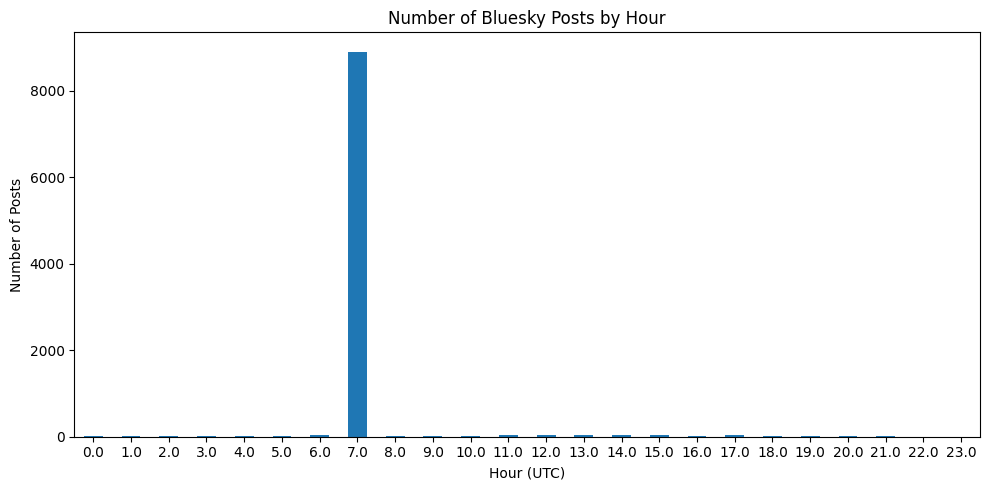

In [16]:
# 4
plt.figure(figsize=(10, 5))

hour_counts.plot(kind="bar")

plt.title("Number of Bluesky Posts by Hour")
plt.xlabel("Hour (UTC)")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [18]:
# ==========================================
# สรุปผล Part 1: Social Listening Warm-up
# ==========================================

n_posts = len(df)
start_date = df["created_at"].min()
end_date = df["created_at"].max()

# ชั่วโมงที่โพสต์มากที่สุด
top_hour = int(hour_counts.idxmax())
top_hour_count = int(hour_counts.max())

# ภาษาหลัก
top_language = language_pct.index[0]
top_language_pct = language_pct.iloc[0]

# Hashtag หลัก
top_hashtag = hashtag_counts.most_common(1)[0][0]
top_hashtag_count = hashtag_counts.most_common(1)[0][1]

print("========== SOCIAL LISTENING SUMMARY ==========")

print(f"จำนวนโพสต์ที่วิเคราะห์: {n_posts:,} โพสต์")
print(f"ช่วงเวลาของข้อมูล: {start_date} ถึง {end_date}")
print(f"ชั่วโมงที่โพสต์มากที่สุด: {top_hour:02d}:00 UTC ({top_hour_count:,} โพสต์)")
print(f"ภาษาที่พบมากที่สุด: {top_language} ({top_language_pct:.2f}%)")
print(f"Hashtag ที่พบมากที่สุด: {top_hashtag} ({top_hashtag_count:,} ครั้ง)")

========== SOCIAL LISTENING SUMMARY ==========
จำนวนโพสต์ที่วิเคราะห์: 10,000 โพสต์
ช่วงเวลาของข้อมูล: 2012-10-27 05:17:45+00:00 ถึง 2024-11-27 16:57:21.275807+00:00
ชั่วโมงที่โพสต์มากที่สุด: 07:00 UTC (8,905 โพสต์)
ภาษาที่พบมากที่สุด: en (49.45%)
Hashtag ที่พบมากที่สุด: #art (23 ครั้ง)



## 1. คนโพสต์เมื่อไร

จากข้อมูลตัวอย่างจำนวน 10,000 โพสต์ พบว่าข้อมูลครอบคลุมช่วงเวลา
[2012-10-27 05:17:45+00:00] ถึง [2024-11-27 16:57:21.275807+00:00]

ช่วงเวลาที่มีการโพสต์มากที่สุดคือ [07:00] UTC
จำนวน [8,905] โพสต์

## 2. ใช้ภาษาอะไร

ภาษาที่พบมากที่สุดคือ [en]
คิดเป็น [49.45]% ของโพสต์ทั้งหมด

ดังนั้น หากต้องการทำคอนเทนต์สำหรับกลุ่มผู้ใช้ในข้อมูลนี้
ควรรองรับภาษา [en] เป็นหลัก

## 3. คนพูดถึงอะไร

Hashtag ที่พบมากที่สุดคือ [#art]
พบทั้งหมด [23] ครั้ง

ตัวอย่างข้อความจริง:

1. akihiko,,,, #artfromtheabyss #fatart #maleweightgain #bhm
2. outdoor studio today. #art #artsed
3. Hug

## 4. ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้

ข้อมูลนี้ช่วยให้เห็นแนวโน้มเบื้องต้นเกี่ยวกับช่วงเวลาการโพสต์
ภาษาที่ใช้ และหัวข้อหรือ hashtag ที่ปรากฏในโพสต์

อย่างไรก็ตาม ไม่สามารถสรุปได้ว่าผู้ใช้ Bluesky ทั้งหมดมีพฤติกรรมเหมือนข้อมูลตัวอย่างนี้
และไม่สามารถใช้ยืนยันสาเหตุหรือความสัมพันธ์เชิงเหตุและผลได้

### ข้อจำกัด

1. วิเคราะห์เพียง 10,000 โพสต์จาก dataset ทั้งหมด จึงอาจไม่เป็นตัวแทนของผู้ใช้ Bluesky ทั้งหมด
2. การตรวจภาษาด้วย `langdetect` เป็นการคาดการณ์จากข้อความและอาจมีความคลาดเคลื่อน
3. โพสต์สั้นมากหรือมีเพียง emoji อาจตรวจภาษาได้ไม่ถูกต้อง
4. การพบ hashtag บ่อยไม่ได้หมายความว่าผู้ใช้มีความคิดเห็นไปในทิศทางเดียวกัน
5. เวลาในกราฟเป็น UTC จึงอาจแตกต่างจากเวลาท้องถิ่นของผู้ใช้

**<สรุปสั้น ๆ ถึงลูกค้า 5 บรรทัด>**


1. จากข้อมูล Bluesky จำนวน 10,000 โพสต์ พบว่าข้อมูลครอบคลุมช่วง 2012-10-27 ถึง 2024-11-27
2. ช่วงเวลาที่มีการโพสต์มากที่สุดคือ 07:00 UTC จำนวน 8,905 โพสต์
3. ภาษาที่พบมากที่สุดคือ en คิดเป็น 49.45% ของโพสต์ทั้งหมด
4. Hashtag ที่โดดเด่นที่สุดคือ #art พบ 23 ครั้ง
5. ผลลัพธ์นี้เป็นการวิเคราะห์จากตัวอย่าง 10,000 โพสต์ จึงใช้เพื่อดูแนวโน้มเบื้องต้น และไม่ควรใช้แทนพฤติกรรมของผู้ใช้ Bluesky ทั้งหมด